# C-MAPSS Modeling — `modeling_v11`
## All 4 subsets · Per-subset RUL clip · Auxiliary degradation state head · t-SNE · GRL on all 3 architectures

**What is new vs v10:**

| Change | v10 | v11 |
|---|---|---|
| RUL clip | 130 uniform | **Per-subset: 125 (FD001/FD003), 145 (FD002/FD004)** |
| Asymmetric loss weight | 1.5 uniform | **1.3** (reduces over-correction on multi-condition subsets) |
| Auxiliary task | None | **Degradation state estimator** (predicts cycle/max_cycle) |
| Representations | Not visualized | **t-SNE** of encoder outputs, colored by subset + RUL bucket |
| Domain adaptation | None | **GRL added to all 3 architectures** (FD001+FD003 → FD002+FD004) |
| Seeds/configs | Single | Single (fast, colab-friendly) |

**Structure:**
- §0-§5: Setup, data, normalization, datasets, eval utils (shared)
- **Part A:** Three base models with per-subset clip + aux state head (TCN, Transformer, TCN-GRU)
- **Part B:** t-SNE visualization of encoder representations
- **Part C:** GRL variants — same 3 encoders + gradient reversal (single-condition → multi-condition DA)
- **§Final:** All-model comparison table

**Wall time on T4 GPU (Colab): ~18 minutes. On M4 MPS: ~30 minutes.**


## §0 · Setup

In [1]:
import os, time, random, math, json, itertools, copy
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.manifold import TSNE

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, ConcatDataset

from tqdm.auto import tqdm
from IPython.display import display, clear_output

if torch.cuda.is_available():             Device = 'cuda'
elif torch.backends.mps.is_available():   Device = 'mps'
else:                                     Device = 'cpu'
print(f'Device : {Device}')
print(f'PyTorch: {torch.__version__}')

sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('CMAPSSData')
CKPT_DIR = Path('checkpoints_v11'); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR  = Path('figures_v11');     FIG_DIR.mkdir(exist_ok=True)
assert DATA_DIR.exists(), 'Place CMAPSSData/ next to this notebook.'

SEED = 42
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed(SEED)
print(f'Seed: {SEED}')

Device : mps
PyTorch: 2.11.0
Seed: 42


## §1 · Constants and data loading

In [2]:
COLS        = (['unit','cycle','setting_1','setting_2','setting_3']
               + [f's_{i}' for i in range(1,22)])
SENSORS_ALL = [c for c in COLS if c.startswith('s_')]
DROP_SENSORS = ['s_1','s_5','s_6','s_10','s_16','s_18','s_19']
USE_SENSORS  = [s for s in SENSORS_ALL if s not in DROP_SENSORS]
SETTINGS     = ['setting_1','setting_2','setting_3']
SUBSETS      = ['FD001','FD002','FD003','FD004']
W            = 30

# Per-subset RUL clip.
# FD001/FD003: single condition, shorter trajectories -> clip 125.
# FD002/FD004: multi-condition, longer trajectories -> clip 145.
# Uniform 130 in v10 under-served the multi-condition tail.
RUL_CLIPS = {'FD001': 125, 'FD002': 145, 'FD003': 125, 'FD004': 145}

# Source domains (single condition) and target domains (multi-condition) for GRL.
SRC_SUBSETS = ['FD001','FD003']
TGT_SUBSETS = ['FD002','FD004']

print(f'Sensors used: {len(USE_SENSORS)} -- {USE_SENSORS}')
print(f'RUL clips: {RUL_CLIPS}')

def load_subset(subset):
    train = pd.read_csv(DATA_DIR/f'train_{subset}.txt', sep=r'\s+',
                        header=None, names=COLS, engine='python')
    test  = pd.read_csv(DATA_DIR/f'test_{subset}.txt',  sep=r'\s+',
                        header=None, names=COLS, engine='python')
    rul   = pd.read_csv(DATA_DIR/f'RUL_{subset}.txt',   sep=r'\s+',
                        header=None, names=['RUL'], engine='python')['RUL'].values
    return train, test, rul

def add_rul(df):
    df = df.copy()
    df['RUL'] = df.groupby('unit')['cycle'].transform('max') - df['cycle']
    return df

raw = {}
for s in SUBSETS:
    tr, te, rul = load_subset(s)
    raw[s] = dict(train=add_rul(tr), test=te, rul=rul)
    print(f'{s}: {tr["unit"].nunique()} train engines  |  {te["unit"].nunique()} test engines')

Sensors used: 14 -- ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
RUL clips: {'FD001': 125, 'FD002': 145, 'FD003': 125, 'FD004': 145}
FD001: 100 train engines  |  100 test engines
FD002: 260 train engines  |  259 test engines
FD003: 100 train engines  |  100 test engines
FD004: 249 train engines  |  248 test engines


## §2 · Regression-based normalization

Same as v10: fit `sensor ~ linear(settings)` on all four training sets, z-score the residual.
No KMeans, no overflow risk, identical function applied to every subset.


In [3]:
def fit_regime_regression(dfs, sensors, settings):
    combined = pd.concat([d[settings + sensors] for d in dfs], ignore_index=True)
    X = combined[settings].values
    return {s: LinearRegression().fit(X, combined[s].values) for s in sensors}

def apply_residual(df, models, sensors, settings):
    df = df.copy(); X = df[settings].values
    for s in sensors:
        df[s] = df[s].values - models[s].predict(X)
    return df

regime_models = fit_regime_regression(
    [raw[s]['train'] for s in SUBSETS], USE_SENSORS, SETTINGS)

all_resid = pd.concat(
    [apply_residual(raw[s]['train'], regime_models, USE_SENSORS, SETTINGS)
     for s in SUBSETS], ignore_index=True)
res_means = all_resid[USE_SENSORS].mean()
res_stds  = all_resid[USE_SENSORS].std().replace(0, 1.0)

def normalize(df):
    df = apply_residual(df, regime_models, USE_SENSORS, SETTINGS)
    df[USE_SENSORS] = (df[USE_SENSORS] - res_means) / res_stds
    return df

norm = {}
for s in SUBSETS:
    norm[s] = dict(train=normalize(raw[s]['train']),
                   test=normalize(raw[s]['test']),
                   rul=raw[s]['rul'])

check = pd.concat([norm[s]['train'] for s in SUBSETS])
print(f'Combined train |mean| max : {check[USE_SENSORS].mean().abs().max():.4f}  (want ~0)')
print(f'Combined train std  mean  : {check[USE_SENSORS].std().mean():.4f}  (want ~1)')

Combined train |mean| max : 0.0000  (want ~0)
Combined train std  mean  : 1.0000  (want ~1)


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value

## §3 · Datasets

**New in v11:** `CMAPSSWindowDataset` stores `cycle_pos` (= cycle / max_cycle, a float in [0,1])
alongside the RUL label. This is the free label for the auxiliary degradation state head.
No extra data needed -- it comes from the trajectory length we already have.

**Per-subset RUL clip** is applied at dataset construction time via `RUL_CLIPS[subset]`.

**Stratified val:** 20% of each subset's engines held out, then combined.
This ensures all four operating-condition regimes appear in the early-stopping signal.


In [4]:
class CMAPSSWindowDataset(Dataset):
    """
    Sliding-window dataset.
    Returns (X, rul_label, cycle_pos) where:
      X         : (W, n_features) float32 window
      rul_label : scalar, clipped RUL
      cycle_pos : scalar in [0,1], = current_cycle / max_cycle (free degradation label)
    """
    def __init__(self, df, sensors, window, rul_clip):
        self.X, self.y, self.pos = [], [], []
        for _, eng in df.groupby('unit'):
            arr      = eng[sensors].values.astype(np.float32)
            cycles   = eng['cycle'].values.astype(np.float32)
            max_cyc  = float(cycles.max())
            ruls     = np.minimum(eng['RUL'].values.astype(np.float32), rul_clip)
            L = len(arr)
            if L < window: continue
            for end in range(window, L + 1):
                self.X.append(arr[end-window:end])
                self.y.append(ruls[end-1])
                self.pos.append(cycles[end-1] / max_cyc)  # 0=start, 1=failure
        self.X   = np.stack(self.X)
        self.y   = np.array(self.y,   dtype=np.float32)
        self.pos = np.array(self.pos, dtype=np.float32)

    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return (torch.from_numpy(self.X[i]),
                torch.tensor(self.y[i]),
                torch.tensor(self.pos[i]))


def build_test_windows(df, sensors, window):
    Xs = []
    for _, eng in df.groupby('unit'):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
        else:
            pad = np.tile(arr[0:1], (window - len(arr), 1))
            Xs.append(np.concatenate([pad, arr], 0))
    return np.stack(Xs)


rng = np.random.default_rng(SEED)
train_datasets, val_datasets = [], []
test_windows, test_ruls = {}, {}

for s in SUBSETS:
    units    = norm[s]['train']['unit'].unique()
    val_u    = rng.choice(units, size=int(0.2 * len(units)), replace=False)
    val_mask = norm[s]['train']['unit'].isin(val_u)
    clip     = RUL_CLIPS[s]

    train_datasets.append(
        CMAPSSWindowDataset(norm[s]['train'][~val_mask], USE_SENSORS, W, clip))
    val_datasets.append(
        CMAPSSWindowDataset(norm[s]['train'][ val_mask], USE_SENSORS, W, clip))
    test_windows[s] = build_test_windows(norm[s]['test'], USE_SENSORS, W)
    test_ruls[s]    = norm[s]['rul'].astype(np.float32)

train_all = ConcatDataset(train_datasets)
val_all   = ConcatDataset(val_datasets)

print('Window counts per subset:')
for i, s in enumerate(SUBSETS):
    print(f'  {s} (clip={RUL_CLIPS[s]}): '
          f'{len(train_datasets[i]):,} train | {len(val_datasets[i]):,} val')
print(f'Combined: {len(train_all):,} train | {len(val_all):,} val')

Window counts per subset:
  FD001 (clip=125): 14,070 train | 3,661 val
  FD002 (clip=145): 36,354 train | 9,865 val
  FD003 (clip=125): 17,655 train | 4,165 val
  FD004 (clip=145): 43,160 train | 10,868 val
Combined: 111,239 train | 28,559 val


## §4 · Evaluation utilities

In [5]:
def asymmetric_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.where(d < 0, np.exp(-d/13.0)-1, np.exp(d/10.0)-1).sum())

def score_predictions(y_true, y_pred_raw, label=''):
    y_pred = np.clip(y_pred_raw, 0, None)
    rmse  = math.sqrt(np.mean((y_pred-y_true)**2))
    score = asymmetric_score(y_true, y_pred)
    mae   = float(np.mean(np.abs(y_pred-y_true)))
    bias  = float((y_pred-y_true).mean())
    if label: print(f'[{label}]')
    print(f'  RMSE={rmse:.3f}  Score={score:.0f}  MAE={mae:.3f}  Bias={bias:+.3f}')
    return dict(rmse=rmse, score=score, mae=mae, bias=bias)

@torch.no_grad()
def run_inference(model, X, device, batch_size=256):
    model.eval(); preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)

@torch.no_grad()
def run_inference_dann(model, X, device, batch_size=256):
    """For DANN models that expose predict_rul()."""
    model.eval(); preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        preds.append(model.predict_rul(xb).cpu().numpy())
    return np.concatenate(preds)

@torch.no_grad()
def evaluate_loader(model, loader, device):
    """Val RMSE on combined loader. Handles 3-tuple batches (X, rul, pos)."""
    model.eval(); sq_err, n = 0.0, 0
    for batch in loader:
        xb, yb = batch[0].to(device), batch[1].to(device)
        sq_err += ((model(xb)-yb)**2).sum().item(); n += len(yb)
    return sq_err/n, math.sqrt(sq_err/n)

def eval_all_subsets(model, device, label='', is_dann=False):
    if label: print(f'\n[{label}]')
    infer = run_inference_dann if is_dann else run_inference
    results = {}
    for s in SUBSETS:
        raw_p = infer(model, test_windows[s], device)
        results[s] = score_predictions(test_ruls[s], raw_p, s)
    return results

def asymmetric_mse(pred, target, late_weight=1.3):
    """Lowered from 1.5 -> 1.3: reduces over-correction on multi-condition subsets."""
    err = pred - target
    w   = torch.where(err > 0, torch.full_like(err, late_weight), torch.ones_like(err))
    return (w * err**2).mean()

## §5 · Shared: TrainTracker + GRL

In [6]:
class TrainTracker:
    def __init__(self, n_epochs, title='', plot_freq=1):
        self.n_epochs=n_epochs; self.plot_freq=plot_freq; self.title=title
        self.epoch=0; self.train_loss=[]; self.val_loss=[]
        self.train_rmse=[]; self.val_rmse=[]
        self._stopped_at=None; self.t0=time.time()
        plt.ioff()
        self.fig,(self.ax_l,self.ax_r)=plt.subplots(1,2,figsize=(13,4))
        self.tl,=self.ax_l.plot([],[],label='train',color='steelblue')
        self.vl,=self.ax_l.plot([],[],label='val',color='darkorange')
        self.tr,=self.ax_r.plot([],[],label='train',color='steelblue')
        self.vr,=self.ax_r.plot([],[],label='val',color='darkorange')
        for ax,yl in [(self.ax_l,'Loss'),(self.ax_r,'RMSE (cycles)')]:
            ax.set_xlim(0,n_epochs+1); ax.set_xlabel('Epoch')
            ax.set_ylabel(yl); ax.legend(); ax.grid(linestyle='--',alpha=0.6)
        self.ax_l.set_title('Loss'); self.ax_r.set_title('Val RMSE')
        plt.tight_layout()
    def update_epoch(self, tl, vl, tr, vr):
        self.train_loss.append(tl); self.val_loss.append(vl)
        self.train_rmse.append(tr); self.val_rmse.append(vr)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()
    def mark_early_stop(self, ep): self._stopped_at = ep
    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        self.tl.set_data(xs,self.train_loss); self.vl.set_data(xs,self.val_loss)
        self.tr.set_data(xs,self.train_rmse); self.vr.set_data(xs,self.val_rmse)
        for ax in (self.ax_l,self.ax_r):
            ax.relim(); ax.autoscale_view()
            if self._stopped_at:
                ax.axvline(self._stopped_at,color='crimson',linestyle=':',lw=1.5)
        elapsed=time.time()-self.t0; eta=(elapsed/max(self.epoch,1))*(self.n_epochs-self.epoch)
        suffix='  [ES]' if self._stopped_at else ''
        self.fig.suptitle(
            f'{self.title}  Ep {self.epoch}/{self.n_epochs}  '
            f'val={self.val_rmse[-1]:.2f}  {elapsed:.0f}s  ETA {eta:.0f}s{suffix}',
            fontsize=10)
        clear_output(wait=True); display(self.fig)
    def close(self): plt.close(self.fig)


# ── Gradient Reversal Layer ───────────────────────────────────────────────────
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.save_for_backward(torch.tensor(lam)); return x.clone()
    @staticmethod
    def backward(ctx, grad):
        lam, = ctx.saved_tensors; return -lam.item() * grad, None

class GradientReversalLayer(nn.Module):
    def __init__(self): super().__init__(); self.lam = 0.0
    def forward(self, x): return GradientReversalFunction.apply(x, self.lam)

def ganin_lambda(epoch, n_epochs, high=1.0):
    p = epoch / n_epochs
    return high * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0)

print('GRL lambda ramp (0->1 over 50 epochs):')
for ep in [0, 5, 15, 25, 40, 50]:
    print(f'  ep {ep:2d}: {ganin_lambda(ep, 50):.4f}')

GRL lambda ramp (0->1 over 50 epochs):
  ep  0: 0.0000
  ep  5: 0.4621
  ep 15: 0.9051
  ep 25: 0.9866
  ep 40: 0.9993
  ep 50: 0.9999


## §6 · Three model architectures

All three architectures expose:
- `encode(x) -> (B, enc_dim)`: the latent representation (needed for t-SNE and GRL)
- `forward(x) -> (B,)`: full forward pass including RUL head + aux state head
- `enc_dim`: attribute so GRL wrapper can read it without hardcoding

**Auxiliary state head:** Each model has a small extra head that predicts `cycle_pos`
(normalized position in engine lifetime). Training loss = `asymmetric_mse(rul) + 0.3 * mse(state)`.
This forces the encoder to learn a genuine degradation representation rather than just
memorizing sensor-to-RUL mappings. The state head is dropped at inference time.


In [7]:
# ── TCN ───────────────────────────────────────────────────────────────────────
class TCNResidualBlock(nn.Module):
    def __init__(self, n_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(n_ch, n_ch, kernel_size, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(n_ch, n_ch, kernel_size, dilation=dilation, padding=pad)
        self.drop  = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(n_ch)
        self.norm2 = nn.LayerNorm(n_ch)
    def _trim(self, x, T): return x[:, :, :T]
    def forward(self, x):
        T = x.size(2)
        h = F.relu(self.norm1(self._trim(self.conv1(x), T).transpose(1,2)).transpose(1,2))
        h = self.drop(h)
        h = F.relu(self.norm2(self._trim(self.conv2(h), T).transpose(1,2)).transpose(1,2))
        return h + x


class TCN(nn.Module):
    def __init__(self, n_features, n_channels=32, kernel_size=3, n_blocks=4, dropout=0.2):
        super().__init__()
        self.enc_dim    = n_channels
        self.input_proj = nn.Conv1d(n_features, n_channels, kernel_size=1)
        self.blocks     = nn.ModuleList([
            TCNResidualBlock(n_channels, kernel_size, 2**i, dropout) for i in range(n_blocks)])
        self.rul_head   = nn.Sequential(nn.Linear(n_channels, 16), nn.ReLU(), nn.Linear(16, 1))
        self.state_head = nn.Sequential(nn.Linear(n_channels, 16), nn.ReLU(),
                                        nn.Linear(16, 1), nn.Sigmoid())

    def encode(self, x):
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        for b in self.blocks: x = b(x)
        return x.mean(dim=2)  # (B, C)

    def forward(self, x):
        h = self.encode(x)
        return self.rul_head(h).squeeze(-1)

    def forward_with_state(self, x):
        h = self.encode(x)
        return self.rul_head(h).squeeze(-1), self.state_head(h).squeeze(-1)


# ── Transformer ───────────────────────────────────────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]


class LightweightTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                 num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.enc_dim    = d_model
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = SinusoidalPE(d_model)
        enc_layer       = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.encoder    = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.rul_head   = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))
        self.state_head = nn.Sequential(nn.Linear(d_model, 16), nn.ReLU(),
                                        nn.Linear(16, 1), nn.Sigmoid())

    def encode(self, x):
        x = self.pos_enc(self.input_proj(x))  # (B, T, d)
        x = self.encoder(x)                   # (B, T, d)
        return x.mean(dim=1)                  # (B, d)

    def forward(self, x):
        return self.rul_head(self.encode(x)).squeeze(-1)

    def forward_with_state(self, x):
        h = self.encode(x)
        return self.rul_head(h).squeeze(-1), self.state_head(h).squeeze(-1)


# ── TCN-GRU hybrid ────────────────────────────────────────────────────────────
class TCNGRUHybrid(nn.Module):
    def __init__(self, n_features, tcn_channels=32, tcn_blocks=3,
                 kernel_size=3, gru_hidden=64, dropout=0.2):
        super().__init__()
        self.enc_dim    = tcn_channels + gru_hidden * 2
        self.tcn_proj   = nn.Conv1d(n_features, tcn_channels, kernel_size=1)
        self.tcn_blocks = nn.ModuleList([
            TCNResidualBlock(tcn_channels, kernel_size, 2**i, dropout)
            for i in range(tcn_blocks)])
        self.gru        = nn.GRU(n_features, gru_hidden, num_layers=1,
                                 batch_first=True, bidirectional=True)
        self.gru_norm   = nn.LayerNorm(gru_hidden * 2)
        self.rul_head   = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(self.enc_dim, 64),
            nn.ReLU(), nn.Linear(64, 1))
        self.state_head = nn.Sequential(
            nn.Linear(self.enc_dim, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

    def encode(self, x):
        t = x.transpose(1, 2)
        t = self.tcn_proj(t)
        for b in self.tcn_blocks: t = b(t)
        tcn_out = t.mean(dim=2)
        out, _  = self.gru(x)
        gru_out = self.gru_norm(out[:, -1, :])
        return torch.cat([tcn_out, gru_out], dim=1)

    def forward(self, x):
        return self.rul_head(self.encode(x)).squeeze(-1)

    def forward_with_state(self, x):
        h = self.encode(x)
        return self.rul_head(h).squeeze(-1), self.state_head(h).squeeze(-1)


# ── Sanity checks ─────────────────────────────────────────────────────────────
_x = torch.randn(4, W, len(USE_SENSORS))
for cls, kwargs, name in [
    (TCN,                  dict(n_features=len(USE_SENSORS)), 'TCN'),
    (LightweightTransformer, dict(n_features=len(USE_SENSORS)), 'Transformer'),
    (TCNGRUHybrid,         dict(n_features=len(USE_SENSORS)), 'TCN-GRU'),
]:
    m = cls(**kwargs)
    rul_p, state_p = m.forward_with_state(_x)
    print(f'{name}: params={sum(p.numel() for p in m.parameters()):,}  '
          f'enc_dim={m.enc_dim}  '
          f'rul_out={tuple(rul_p.shape)}  state_out={tuple(state_p.shape)}')
del _x

TCN: params=26,914  enc_dim=32  rul_out=(4,)  state_out=(4,)
Transformer: params=71,074  enc_dim=64  rul_out=(4,)  state_out=(4,)
TCN-GRU: params=66,018  enc_dim=160  rul_out=(4,)  state_out=(4,)


## §7 · Training loop (with aux state loss)

**Total loss = asymmetric_mse(rul_pred, rul_true) + 0.3 * mse(state_pred, cycle_pos)**

The 0.3 weight keeps the state task as a regularizer. At val time and inference,
only the RUL head is used (RMSE is computed on RUL predictions only).

Val loader uses the same 3-tuple batch format; the third element (cycle_pos) is
ignored during val evaluation since we only care about RUL RMSE for early stopping.


In [8]:
def train_model(
    model, train_loader, val_loader,
    n_epochs=60, lr=5e-4, weight_decay=1e-4,
    grad_clip=1.0, patience=15, late_weight=1.3,
    state_weight=0.3,   # aux degradation state loss weight
    device=Device, ckpt_path=None, tracker_title='',
):
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    tracker = TrainTracker(n_epochs, title=tracker_title)
    history = []
    best_val=float('inf'); best_epoch=0; no_improve=0; best_state=None

    pbar = tqdm(range(1, n_epochs+1), desc=tracker_title or 'Train', unit='epoch')
    for epoch in pbar:
        model.train()
        ep_loss, ep_sq, ep_n = 0.0, 0.0, 0
        for xb, yb, pos_b in train_loader:
            xb, yb, pos_b = xb.to(device), yb.to(device), pos_b.to(device)
            rul_pred, state_pred = model.forward_with_state(xb)
            loss = (asymmetric_mse(rul_pred, yb, late_weight)
                    + state_weight * F.mse_loss(state_pred, pos_b))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += loss.item()*len(yb)
            ep_sq   += ((rul_pred-yb)**2).sum().item(); ep_n += len(yb)
        sched.step()
        train_rmse = math.sqrt(ep_sq/ep_n)
        _, val_rmse = evaluate_loader(model, val_loader, device)
        history.append(dict(epoch=epoch, train_loss=ep_loss/ep_n,
                            train_rmse=train_rmse, val_rmse=val_rmse))
        tracker.update_epoch(ep_loss/ep_n, ep_loss/ep_n, train_rmse, val_rmse)
        pbar.set_postfix({'val': f'{val_rmse:.2f}', 'no_imp': no_improve})
        if val_rmse < best_val:
            best_val=val_rmse; best_epoch=epoch; no_improve=0
            best_state = copy.deepcopy(model.state_dict())
            if ckpt_path:
                torch.save({'model': best_state, 'epoch': epoch,
                            'val_rmse': val_rmse}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                tracker.mark_early_stop(epoch); tracker._redraw(); break
    tracker.close()
    print(f'Best val RMSE = {best_val:.3f} at epoch {best_epoch}')
    if best_state: model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

---
# Part A · Base models (TCN, Transformer, TCN-GRU)
---

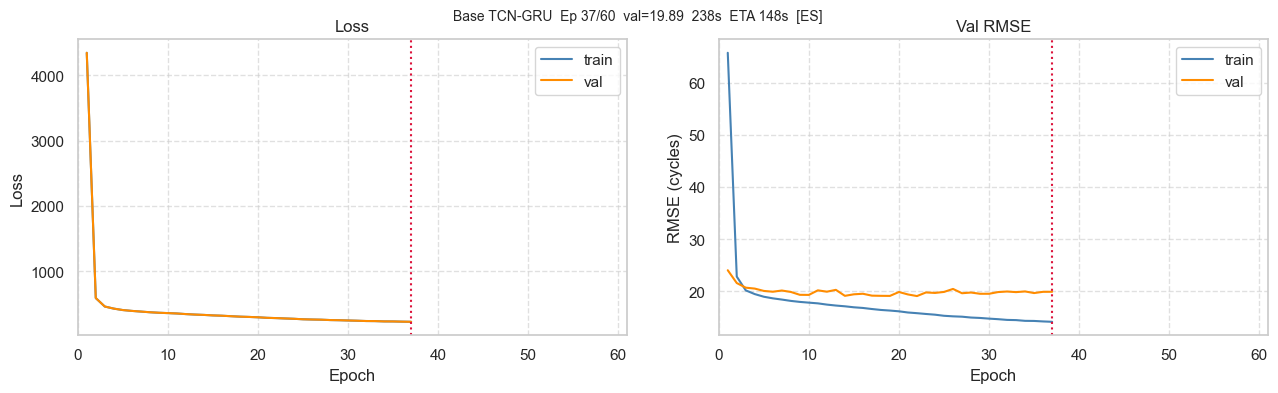

Best val RMSE = 19.065 at epoch 22

[Base TCN-GRU]
[FD001]
  RMSE=15.011  Score=404  MAE=11.094  Bias=-0.191
[FD002]
  RMSE=25.359  Score=10661  MAE=17.029  Bias=-4.446
[FD003]
  RMSE=15.319  Score=442  MAE=11.787  Bias=+3.620
[FD004]
  RMSE=24.056  Score=3404  MAE=18.558  Bias=-1.989


In [11]:
BATCH = 512
train_loader = DataLoader(train_all, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_all,   batch_size=BATCH, shuffle=False, num_workers=0)

base_metrics = {}

model_specs = [
    ('TCN',         TCN(len(USE_SENSORS), n_channels=32, dropout=0.2)),
    ('Transformer', LightweightTransformer(len(USE_SENSORS), d_model=64, nhead=4,
                                           dim_feedforward=128, dropout=0.1)),
    ('TCN-GRU',     TCNGRUHybrid(len(USE_SENSORS), tcn_channels=32, gru_hidden=64,
                                  dropout=0.2)),
]

for name, model in model_specs:
    print('=' * 55)
    print(f'Training base {name}  ({sum(p.numel() for p in model.parameters()):,} params)')
    print('=' * 55)
    set_seed(SEED)
    model, hist = train_model(
        model, train_loader, val_loader,
        n_epochs=60, lr=5e-4, weight_decay=1e-4,
        grad_clip=1.0, patience=15, late_weight=1.3, state_weight=0.3,
        device=Device, ckpt_path=CKPT_DIR/f'base_{name.lower().replace("-","_")}.pt',
        tracker_title=f'Base {name}',
    )
    base_metrics[name] = eval_all_subsets(model, Device, f'Base {name}')
    hist.to_csv(CKPT_DIR/f'base_{name.lower().replace("-","_")}_hist.csv', index=False)
    # Keep the trained model object for t-SNE
    model_specs[model_specs.index((name, model))] = (name, model)

In [12]:
# ── Base model results table ───────────────────────────────────────────────────
print('\n=== Part A Results ===')
for name in ['TCN','Transformer','TCN-GRU']:
    print(f'  [{name}]')
    for s in SUBSETS:
        m = base_metrics[name][s]
        print(f'    {s}: RMSE={m["rmse"]:.2f}  Score={m["score"]:.0f}  Bias={m["bias"]:+.2f}')

print('\n  [v10 Transformer reference (uniform clip=130, late_weight=1.5)]')
v10_ref = {'FD001':14.93,'FD002':25.03,'FD003':14.74,'FD004':24.88}
for s,r in v10_ref.items(): print(f'    {s}: RMSE={r:.2f}')


=== Part A Results ===
  [TCN]
    FD001: RMSE=15.44  Score=431  Bias=+2.22
    FD002: RMSE=26.20  Score=10813  Bias=-1.22
    FD003: RMSE=15.56  Score=502  Bias=+3.87
    FD004: RMSE=24.72  Score=5319  Bias=+0.13
  [Transformer]
    FD001: RMSE=14.82  Score=399  Bias=-0.35
    FD002: RMSE=24.48  Score=5914  Bias=-2.97
    FD003: RMSE=14.30  Score=330  Bias=+0.66
    FD004: RMSE=24.22  Score=5146  Bias=-3.48
  [TCN-GRU]
    FD001: RMSE=15.01  Score=404  Bias=-0.19
    FD002: RMSE=25.36  Score=10661  Bias=-4.45
    FD003: RMSE=15.32  Score=442  Bias=+3.62
    FD004: RMSE=24.06  Score=3404  Bias=-1.99

  [v10 Transformer reference (uniform clip=130, late_weight=1.5)]
    FD001: RMSE=14.93
    FD002: RMSE=25.03
    FD003: RMSE=14.74
    FD004: RMSE=24.88


---
# Part B · t-SNE of encoder representations

For each base model, extract encoder outputs for a random sample of 2000 windows
(500 from each subset), run t-SNE, and plot colored by:
1. **Subset** — do the four subsets cluster separately or overlap?
2. **RUL bucket** — do healthy/mid/degraded windows form consistent groups?

With v9 (FD001-only training), FD001 and FD002 formed completely separate blobs.
With multi-dataset training the blobs should overlap and RUL ordering should appear
within each region.

---

Running t-SNE for TCN  (encodings shape: (2000, 32))...


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main

Running t-SNE for Transformer  (encodings shape: (2000, 64))...


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main

Running t-SNE for TCN-GRU  (encodings shape: (2000, 160))...


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/main

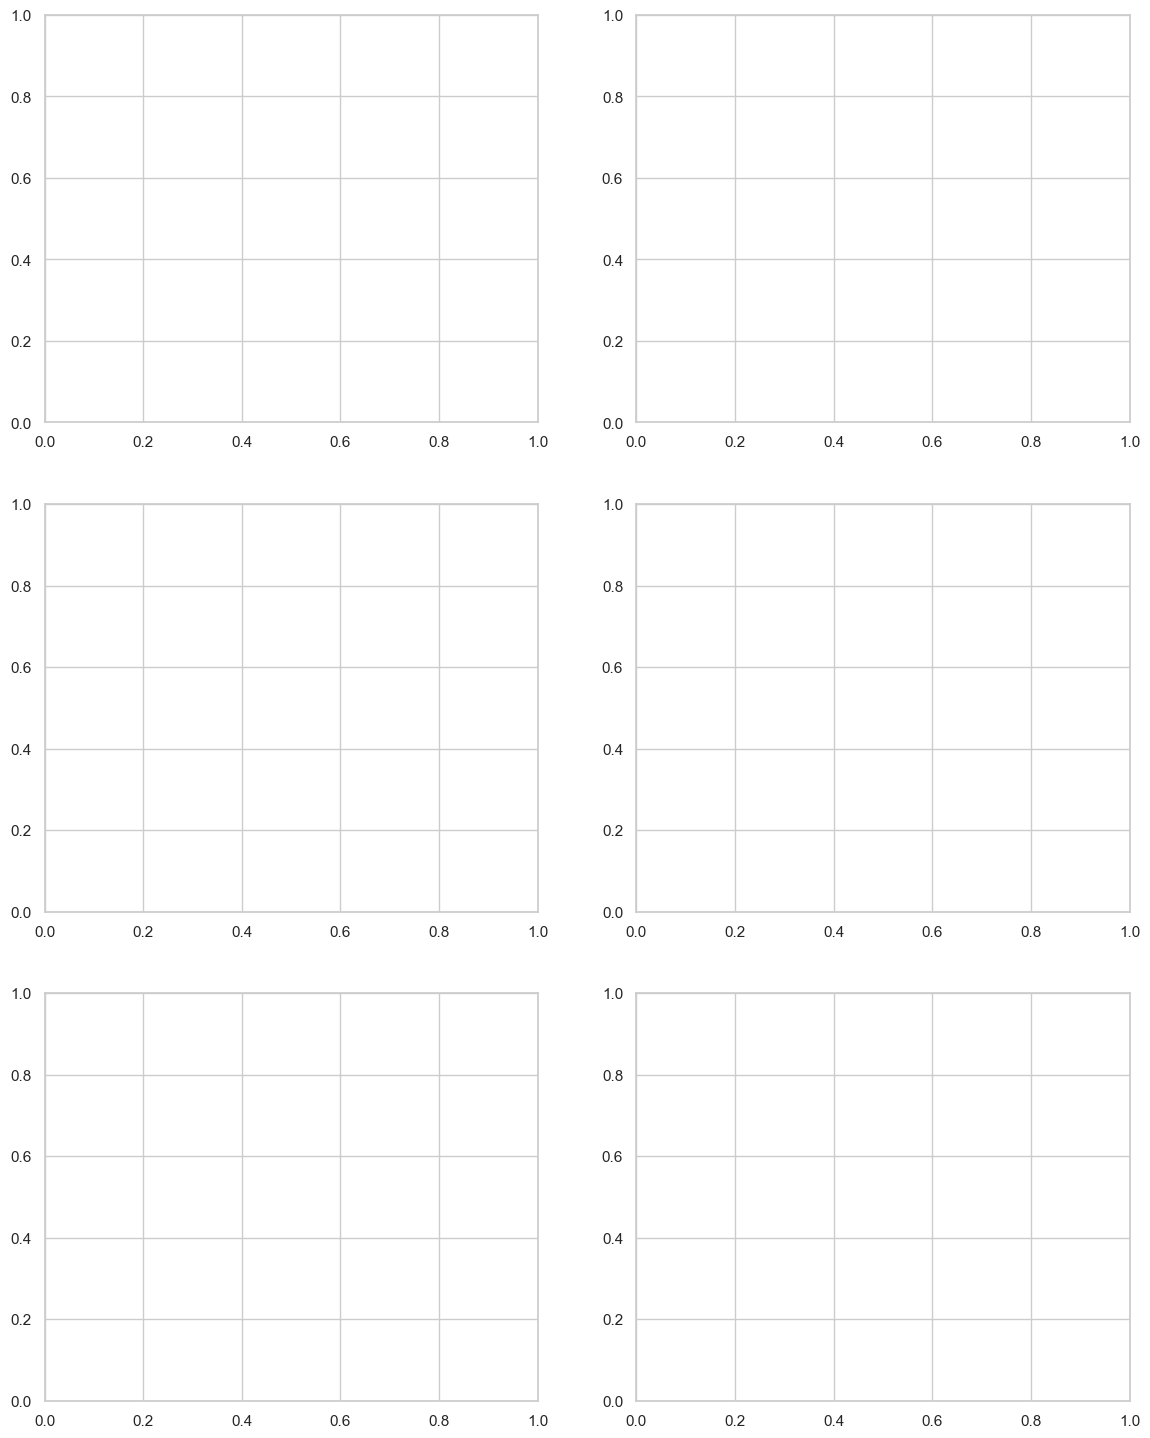

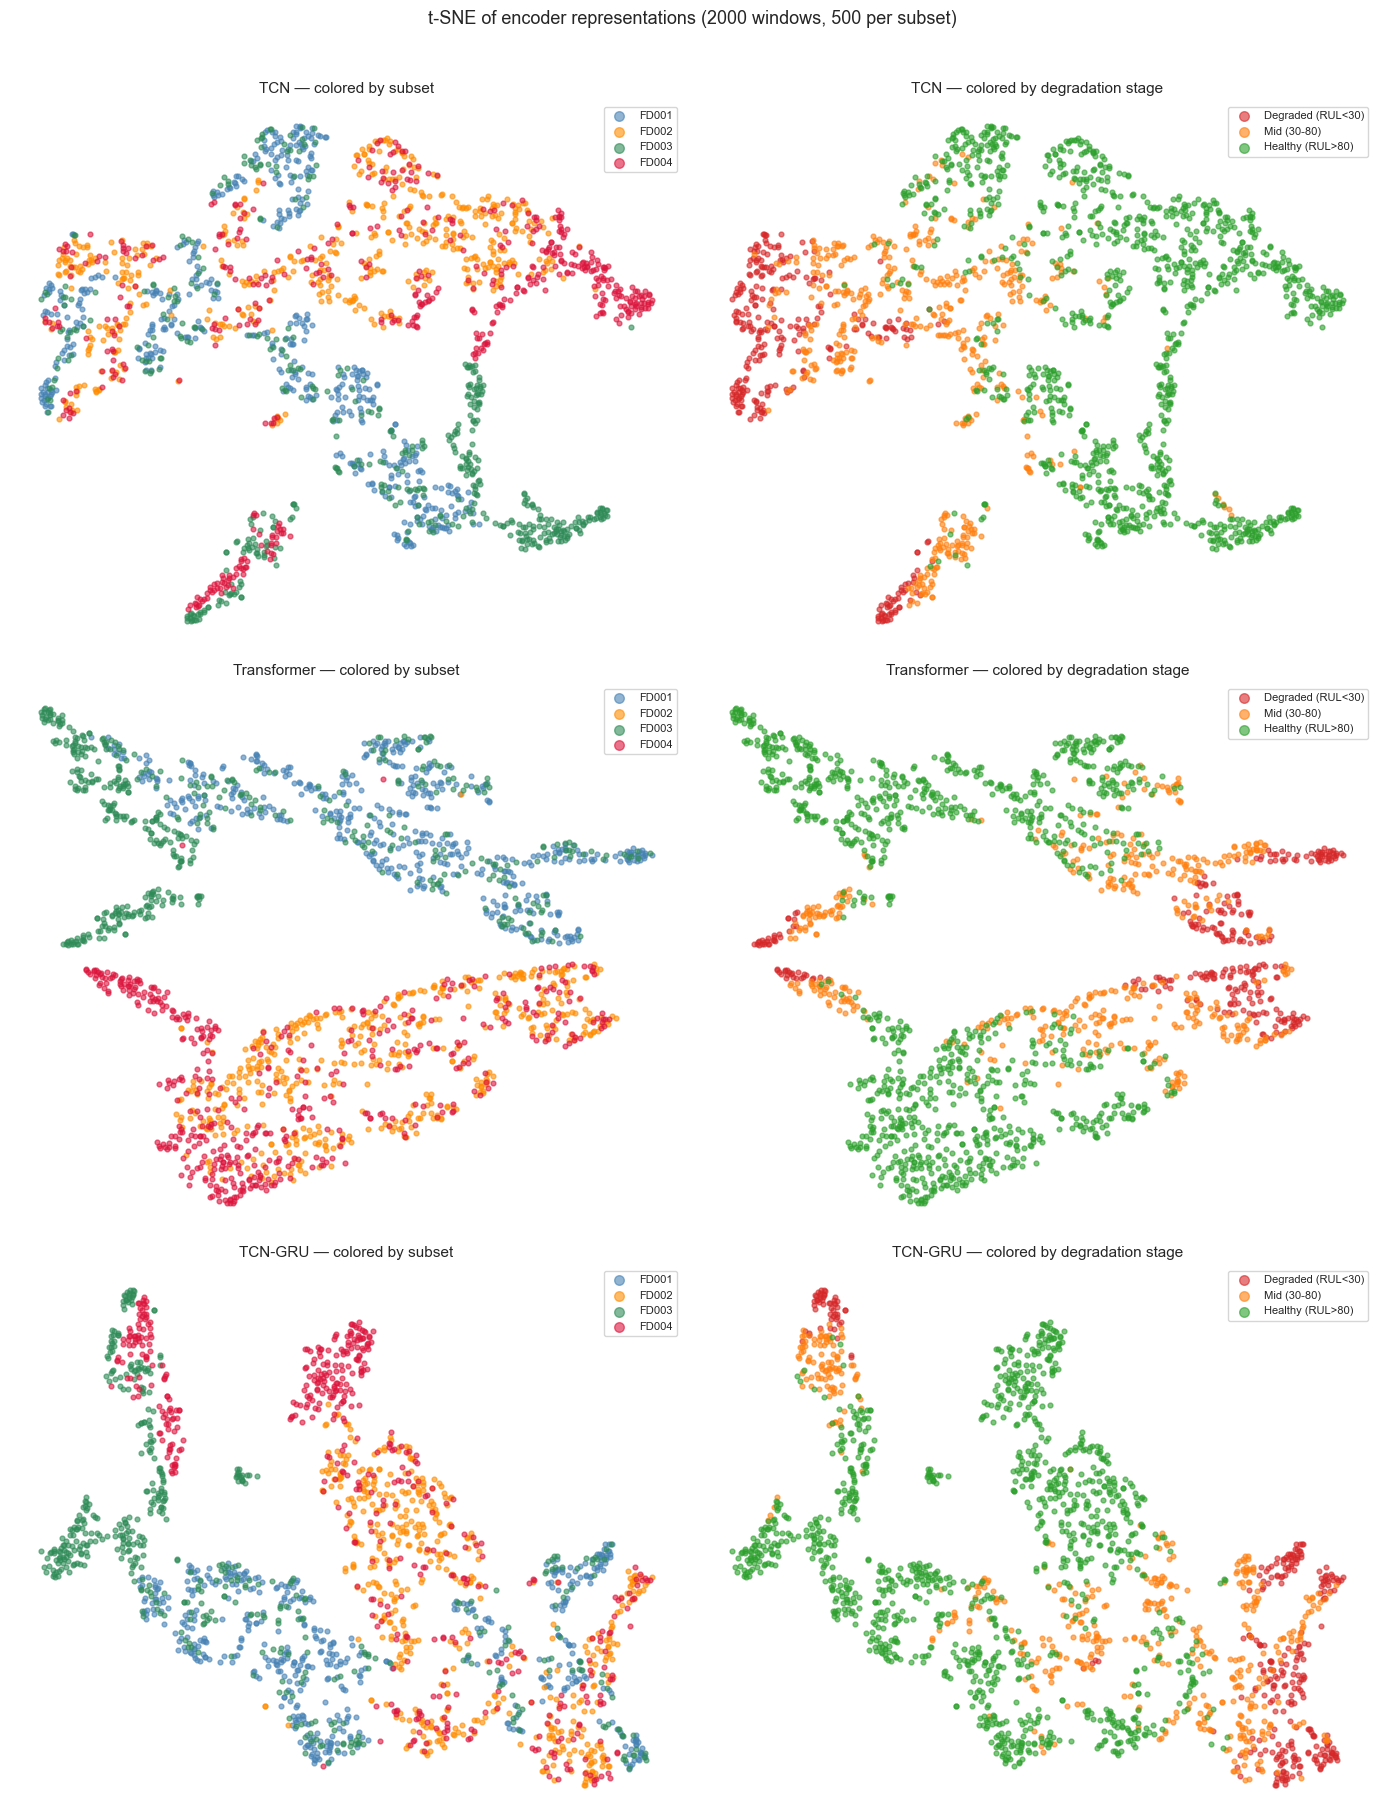

Saved -> figures_v11/v11_tsne.png


In [14]:
@torch.no_grad()
def extract_encodings(model, datasets, device, n_per_subset=500, seed=0):
    """
    Sample n_per_subset windows from each subset's train dataset,
    run through model.encode(), return (encodings, subset_labels, rul_values).
    """
    model.eval()
    rng = np.random.default_rng(seed)
    all_enc, all_sub, all_rul = [], [], []

    for sub_idx, s in enumerate(SUBSETS):
        ds    = datasets[sub_idx]
        idxs  = rng.choice(len(ds), size=min(n_per_subset, len(ds)), replace=False)
        Xs    = torch.from_numpy(ds.X[idxs]).to(device)
        enc   = model.encode(Xs).cpu().numpy()
        ruls  = ds.y[idxs]
        all_enc.append(enc)
        all_sub.append(np.full(len(idxs), sub_idx))
        all_rul.append(ruls)

    return (np.concatenate(all_enc),
            np.concatenate(all_sub),
            np.concatenate(all_rul))


def rul_to_bucket(ruls):
    """0=degraded (RUL<30), 1=mid (30-80), 2=healthy (RUL>80)."""
    buckets = np.zeros(len(ruls), dtype=int)
    buckets[ruls >= 30]  = 1
    buckets[ruls >= 80]  = 2
    return buckets


SUBSET_COLORS = ['steelblue','darkorange','seagreen','crimson']
BUCKET_COLORS = ['#d62728','#ff7f0e','#2ca02c']  # degraded=red, mid=orange, healthy=green
BUCKET_NAMES  = ['Degraded (RUL<30)','Mid (30-80)','Healthy (RUL>80)']

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for row, (name, model) in enumerate(model_specs):
    enc, sub_labels, rul_vals = extract_encodings(model, train_datasets, Device,
                                                   n_per_subset=500, seed=SEED)
    print(f'Running t-SNE for {name}  (encodings shape: {enc.shape})...')
    tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
    coords = tsne.fit_transform(enc)

    # Left: colored by subset
    ax = axes[row, 0]
    for i, s in enumerate(SUBSETS):
        mask = sub_labels == i
        ax.scatter(coords[mask,0], coords[mask,1], c=SUBSET_COLORS[i],
                   s=12, alpha=0.6, label=s)
    ax.set_title(f'{name} — colored by subset', fontsize=11)
    ax.legend(fontsize=8, markerscale=2); ax.axis('off')

    # Right: colored by RUL bucket
    ax = axes[row, 1]
    buckets = rul_to_bucket(rul_vals)
    for b, (c, lbl) in enumerate(zip(BUCKET_COLORS, BUCKET_NAMES)):
        mask = buckets == b
        ax.scatter(coords[mask,0], coords[mask,1], c=c,
                   s=12, alpha=0.6, label=lbl)
    ax.set_title(f'{name} — colored by degradation stage', fontsize=11)
    ax.legend(fontsize=8, markerscale=2); ax.axis('off')

plt.suptitle('t-SNE of encoder representations (2000 windows, 500 per subset)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'v11_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v11_tsne.png')

---
# Part C · GRL variants — domain adversarial adaptation

**Setup:** FD001 + FD003 (single-condition) are the **source domain** (labeled).
FD002 + FD004 (multi-condition) are the **target domain** (unlabeled during DA).

The GRL wrapper takes any of the three base encoders and adds:
- A domain classifier head (binary: source vs target)
- A GRL between the encoder output and the domain head
- Two-phase training: 10 epochs warmup (pure RUL), then Ganin ramp

This is distinct from the multi-dataset training above: the base models train on
ALL four subsets with RUL labels. The GRL models train on FD001/FD003 with RUL labels
+ FD002/FD004 as unlabeled target, asking whether explicit domain alignment on top
of multi-dataset training makes things even better.

---

In [18]:
class GRLWrapper(nn.Module):
    """
    Wraps any encoder that has .encode(x), .rul_head, .state_head, .enc_dim.
    Adds a domain classifier head behind a GRL.

    Training: forward(x_src, x_tgt) -> (rul_pred, state_pred, dom_logits)
    Inference: predict_rul(x) -> scalar predictions
    """
    def __init__(self, encoder: nn.Module):
        super().__init__()
        self.encoder     = encoder
        self.grl         = GradientReversalLayer()
        enc_dim          = encoder.enc_dim
        self.domain_head = nn.Sequential(
            nn.Linear(enc_dim, 32), nn.ReLU(), nn.Linear(32, 1)
        )

    def predict_rul(self, x):
        return self.encoder(x)

    def forward(self, x_src, x_tgt):
        h_src     = self.encoder.encode(x_src)
        h_tgt     = self.encoder.encode(x_tgt)

        rul_pred   = self.encoder.rul_head(h_src).squeeze(-1)
        state_pred = self.encoder.state_head(h_src).squeeze(-1)

        h_all      = torch.cat([h_src, h_tgt], dim=0)
        dom_logits = self.domain_head(self.grl(h_all)).squeeze(-1)
        return rul_pred, state_pred, dom_logits


# ── GRL training loop ─────────────────────────────────────────────────────────
class DANNTracker:
    def __init__(self, n_epochs, title='', plot_freq=1):
        self.n_epochs=n_epochs; self.plot_freq=plot_freq; self.title=title
        self.epoch=0
        self.total_loss=[]; self.rul_loss=[]; self.dom_loss=[]; self.val_rmse=[]; self.lam_hist=[]
        self._stopped_at=None; self.t0=time.time()
        plt.ioff()
        self.fig, axes = plt.subplots(2, 2, figsize=(13, 7))
        (self.ax_tot, self.ax_val), (self.ax_rul, self.ax_dom) = axes
        self.c_tot,=self.ax_tot.plot([],[],color='steelblue')
        self.c_val,=self.ax_val.plot([],[],color='darkorange')
        self.c_rul,=self.ax_rul.plot([],[],color='seagreen')
        self.c_dom,=self.ax_dom.plot([],[],color='mediumpurple')
        self.ax_dom2=self.ax_dom.twinx()
        self.c_lam,=self.ax_dom2.plot([],[],color='gray',linestyle='--',alpha=0.7)
        for ax,t,yl in [(self.ax_tot,'Total loss','Loss'),(self.ax_val,'Val RMSE (src)','RMSE'),
                        (self.ax_rul,'RUL loss','Loss'),(self.ax_dom,'Domain BCE','BCE')]:
            ax.set_title(t); ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
            ax.set_xlim(0,n_epochs+1); ax.grid(linestyle='--',alpha=0.6)
        self.ax_dom2.set_ylabel('lambda'); plt.tight_layout()
    def update_epoch(self, tot, rul, dom, vr, lam):
        self.total_loss.append(tot); self.rul_loss.append(rul)
        self.dom_loss.append(dom); self.val_rmse.append(vr); self.lam_hist.append(lam)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs: self._redraw()
    def mark_early_stop(self, ep): self._stopped_at = ep
    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        for c,d,ax in [(self.c_tot,self.total_loss,self.ax_tot),(self.c_val,self.val_rmse,self.ax_val),
                       (self.c_rul,self.rul_loss,self.ax_rul),(self.c_dom,self.dom_loss,self.ax_dom)]:
            c.set_data(xs,d); ax.relim(); ax.autoscale_view()
        self.c_lam.set_data(xs,self.lam_hist); self.ax_dom2.relim(); self.ax_dom2.autoscale_view()
        if self._stopped_at:
            for ax in (self.ax_tot,self.ax_val,self.ax_rul,self.ax_dom):
                ax.axvline(self._stopped_at,color='crimson',linestyle=':',lw=1.5)
        elapsed=time.time()-self.t0; eta=(elapsed/max(self.epoch,1))*(self.n_epochs-self.epoch)
        suffix='  [ES]' if self._stopped_at else ''
        self.fig.suptitle(
            f'{self.title}  Ep {self.epoch}/{self.n_epochs}  '
            f'val={self.val_rmse[-1]:.2f}  lam={self.lam_hist[-1]:.3f}  '
            f'{elapsed:.0f}s  ETA {eta:.0f}s{suffix}', fontsize=10)
        clear_output(wait=True); display(self.fig)
    def close(self): plt.close(self.fig)


def train_grl(
    grl_model: GRLWrapper,
    src_loader, tgt_loader, val_loader,
    warmup_epochs=10, total_epochs=60,
    lr=5e-4, weight_decay=1e-4,
    grad_clip=1.0, patience=15,
    late_weight=1.3, state_weight=0.3, lambda_max=1.0,
    device=Device, ckpt_path=None, tracker_title='',
):
    grl_model  = grl_model.to(device)
    opt        = optim.Adam(grl_model.parameters(), lr=lr, weight_decay=weight_decay)
    sched      = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_epochs)
    dom_crit   = nn.BCEWithLogitsLoss()
    tracker    = DANNTracker(total_epochs, title=tracker_title)
    history    = []
    phase2_eps = total_epochs - warmup_epochs
    best_val=float('inf'); best_epoch=0; no_improve=0; best_state=None

    pbar = tqdm(range(1, total_epochs+1), desc=tracker_title, unit='epoch')
    for epoch in pbar:
        # Phase 1: warmup -- GRL is identity (lam=0)
        # Phase 2: Ganin ramp
        lam = 0.0 if epoch <= warmup_epochs else ganin_lambda(
            epoch - warmup_epochs, phase2_eps, high=lambda_max)
        grl_model.grl.lam = lam
        grl_model.train()
        ep_tot, ep_rul, ep_dom, ep_n = 0.0, 0.0, 0.0, 0

        tgt_iter = itertools.cycle(tgt_loader)
        for x_src, y_src, pos_src in src_loader:
            x_tgt_batch = next(tgt_iter)[0]  # only X needed from target
            x_src, y_src = x_src.to(device), y_src.to(device)
            pos_src      = pos_src.to(device)
            x_tgt_batch  = x_tgt_batch.to(device)

            rul_pred, state_pred, dom_logits = grl_model(x_src, x_tgt_batch)
            B_src = x_src.size(0); B_tgt = x_tgt_batch.size(0)
            dom_labels = torch.cat([torch.zeros(B_src, device=device),
                                    torch.ones(B_tgt,  device=device)])
            l_rul   = asymmetric_mse(rul_pred, y_src, late_weight)
            l_state = F.mse_loss(state_pred, pos_src)
            l_dom   = dom_crit(dom_logits, dom_labels)
            loss    = l_rul + state_weight * l_state + lam * l_dom

            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(grl_model.parameters(), grad_clip)
            opt.step()
            ep_tot += loss.item()*B_src; ep_rul += l_rul.item()*B_src
            ep_dom += l_dom.item()*B_src; ep_n  += B_src

        sched.step()
        _, val_rmse = evaluate_loader(grl_model.encoder, val_loader, device)
        history.append(dict(epoch=epoch, total_loss=ep_tot/ep_n,
                            rul_loss=ep_rul/ep_n, dom_loss=ep_dom/ep_n,
                            val_rmse=val_rmse, lam=lam))
        tracker.update_epoch(ep_tot/ep_n, ep_rul/ep_n, ep_dom/ep_n, val_rmse, lam)
        pbar.set_postfix({'val': f'{val_rmse:.2f}', 'lam': f'{lam:.3f}',
                          'phase': 'P1' if epoch <= warmup_epochs else 'P2',
                          'no_imp': no_improve})

        if val_rmse < best_val:
            best_val=val_rmse; best_epoch=epoch; no_improve=0
            best_state = copy.deepcopy(grl_model.state_dict())
            if ckpt_path:
                torch.save({'model': best_state, 'epoch': epoch,
                            'val_rmse': val_rmse}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                tracker.mark_early_stop(epoch); tracker._redraw(); break

    tracker.close()
    print(f'Best val RMSE = {best_val:.3f} at epoch {best_epoch}')
    if best_state: grl_model.load_state_dict(best_state)
    return grl_model, pd.DataFrame(history)

In [19]:
# ── GRL datasets: source = FD001+FD003 (labeled), target = FD002+FD004 (unlabeled) ──
src_train  = ConcatDataset([train_datasets[SUBSETS.index(s)] for s in SRC_SUBSETS])
tgt_train  = ConcatDataset([train_datasets[SUBSETS.index(s)] for s in TGT_SUBSETS])
src_val    = ConcatDataset([val_datasets[SUBSETS.index(s)]   for s in SRC_SUBSETS])

src_loader_grl = DataLoader(src_train, batch_size=256, shuffle=True,  num_workers=0)
tgt_loader_grl = DataLoader(tgt_train, batch_size=256, shuffle=True,  num_workers=0)
src_val_loader = DataLoader(src_val,   batch_size=256, shuffle=False, num_workers=0)

print(f'GRL source train: {len(src_train):,} windows ({SRC_SUBSETS})')
print(f'GRL target train: {len(tgt_train):,} windows ({TGT_SUBSETS}, unlabeled)')
print(f'GRL source val  : {len(src_val):,} windows')

GRL source train: 31,725 windows (['FD001', 'FD003'])
GRL target train: 79,514 windows (['FD002', 'FD004'], unlabeled)
GRL source val  : 7,826 windows


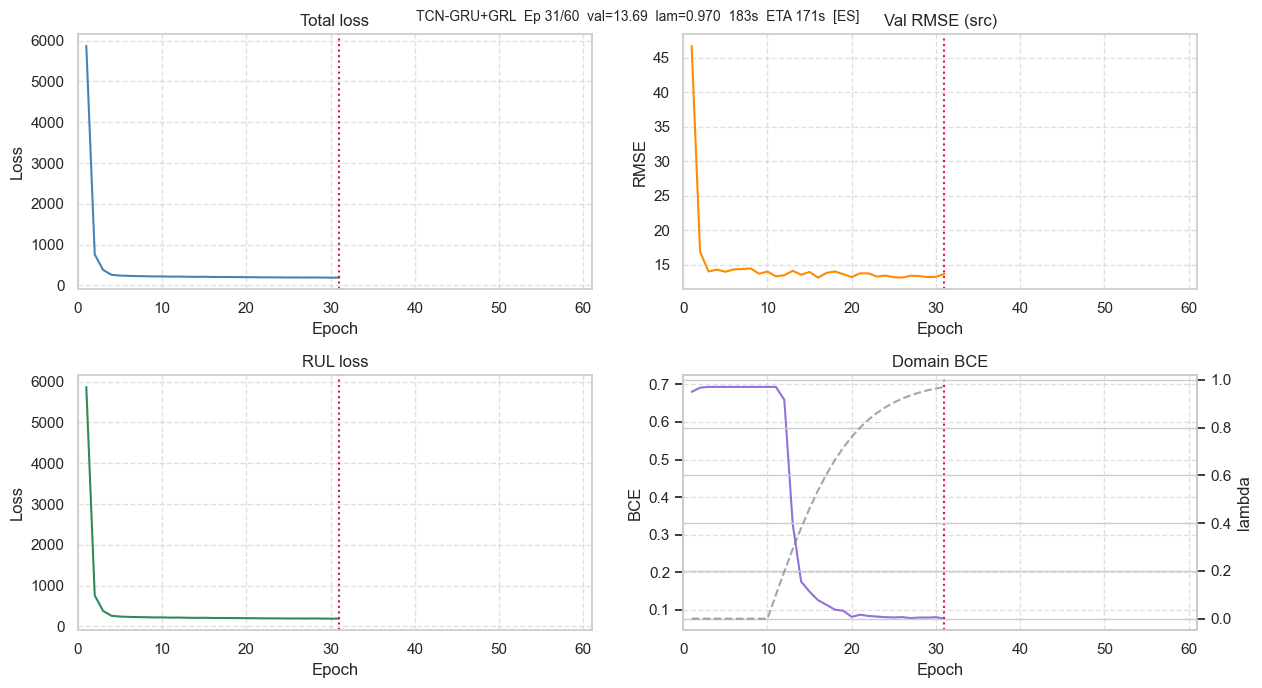

Best val RMSE = 13.151 at epoch 16

[TCN-GRU+GRL]
[FD001]
  RMSE=15.212  Score=435  MAE=10.662  Bias=-0.248
[FD002]
  RMSE=57.959  Score=3350058  MAE=45.321  Bias=-30.062
[FD003]
  RMSE=15.595  Score=559  MAE=11.493  Bias=+2.415
[FD004]
  RMSE=56.311  Score=2169972  MAE=43.049  Bias=-29.067


In [20]:
# ── Train GRL on all three architectures ──────────────────────────────────────
grl_metrics = {}

grl_specs = [
    ('TCN+GRL',         TCN(len(USE_SENSORS), n_channels=32, dropout=0.2)),
    ('Transformer+GRL', LightweightTransformer(len(USE_SENSORS), d_model=64, nhead=4,
                                               dim_feedforward=128, dropout=0.1)),
    ('TCN-GRU+GRL',     TCNGRUHybrid(len(USE_SENSORS), tcn_channels=32,
                                      gru_hidden=64, dropout=0.2)),
]

for name, encoder in grl_specs:
    print(f'\n{"="*55}')
    print(f'Training {name}')
    print(f'{"="*55}')
    set_seed(SEED)
    grl_model = GRLWrapper(encoder)
    total_params = sum(p.numel() for p in grl_model.parameters())
    print(f'Total params (encoder + domain head): {total_params:,}')

    safe_name = name.lower().replace('+','_').replace('-','_')
    grl_model, grl_hist = train_grl(
        grl_model,
        src_loader=src_loader_grl,
        tgt_loader=tgt_loader_grl,
        val_loader=src_val_loader,
        warmup_epochs=10, total_epochs=60,
        lr=5e-4, weight_decay=1e-4,
        grad_clip=1.0, patience=15,
        late_weight=1.3, state_weight=0.3, lambda_max=1.0,
        device=Device,
        ckpt_path=CKPT_DIR/f'grl_{safe_name}.pt',
        tracker_title=name,
    )
    grl_metrics[name] = eval_all_subsets(grl_model, Device, name, is_dann=True)
    grl_hist.to_csv(CKPT_DIR/f'grl_{safe_name}_hist.csv', index=False)

---
# Final comparison
---

In [21]:
# ── Full comparison table ──────────────────────────────────────────────────────
all_model_results = {}
for name in ['TCN','Transformer','TCN-GRU']:
    all_model_results[name]         = base_metrics[name]
    all_model_results[name+'+GRL']  = grl_metrics.get(name+'+GRL', {})

print('='*75)
print('FINAL SUMMARY — v11')
print('='*75)

# RMSE summary
rows = []
for mname, mres in all_model_results.items():
    if not mres: continue
    row = {'Model': mname}
    for s in SUBSETS:
        row[f'{s}'] = f"{mres[s]['rmse']:.2f}"
    rows.append(row)

# Add references
rows.append({'Model': 'v10 Transformer (uniform clip)',
             'FD001':'14.93','FD002':'25.03','FD003':'14.74','FD004':'24.88'})
rows.append({'Model': 'v9 BiGRU FD001-only',
             'FD001':'14.58','FD002':'59.51','FD003':'—','FD004':'—'})
rows.append({'Model': 'Zheng 2017',
             'FD001':'16.10','FD002':'—','FD003':'—','FD004':'—'})

rmse_df = pd.DataFrame(rows)
print('\nTest RMSE (lower is better):')
print(rmse_df.to_string(index=False))

# Bias summary
rows_bias = []
for mname, mres in all_model_results.items():
    if not mres: continue
    row = {'Model': mname}
    for s in SUBSETS:
        row[f'{s}'] = f"{mres[s]['bias']:+.2f}"
    rows_bias.append(row)
bias_df = pd.DataFrame(rows_bias)
print('\nBias (+= late/optimistic, -= early/conservative):')
print(bias_df.to_string(index=False))

# GRL gap analysis
print('\nGRL improvement over base (RMSE reduction on FD002+FD004):')
for enc_name in ['TCN','Transformer','TCN-GRU']:
    grl_name = enc_name + '+GRL'
    if grl_name not in grl_metrics: continue
    for s in TGT_SUBSETS:
        base_r = base_metrics[enc_name][s]['rmse']
        grl_r  = grl_metrics[grl_name][s]['rmse']
        delta  = base_r - grl_r
        print(f'  {enc_name} on {s}: {base_r:.2f} -> {grl_r:.2f}  (delta={delta:+.2f})')

FINAL SUMMARY — v11

Test RMSE (lower is better):
                         Model FD001 FD002 FD003 FD004
                           TCN 15.44 26.20 15.56 24.72
                       TCN+GRL 15.53 53.21 15.76 52.72
                   Transformer 14.82 24.48 14.30 24.22
               Transformer+GRL 13.48 42.25 13.95 41.45
                       TCN-GRU 15.01 25.36 15.32 24.06
                   TCN-GRU+GRL 15.21 57.96 15.59 56.31
v10 Transformer (uniform clip) 14.93 25.03 14.74 24.88
           v9 BiGRU FD001-only 14.58 59.51     —     —
                    Zheng 2017 16.10     —     —     —

Bias (+= late/optimistic, -= early/conservative):
          Model FD001  FD002 FD003  FD004
            TCN +2.22  -1.22 +3.87  +0.13
        TCN+GRL +0.17 -34.34 +1.29 -35.67
    Transformer -0.35  -2.97 +0.66  -3.48
Transformer+GRL +0.15 +11.62 +0.36  +6.60
        TCN-GRU -0.19  -4.45 +3.62  -1.99
    TCN-GRU+GRL -0.25 -30.06 +2.42 -29.07

GRL improvement over base (RMSE reduction on FD002+FD0

/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_33494/2432801786.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


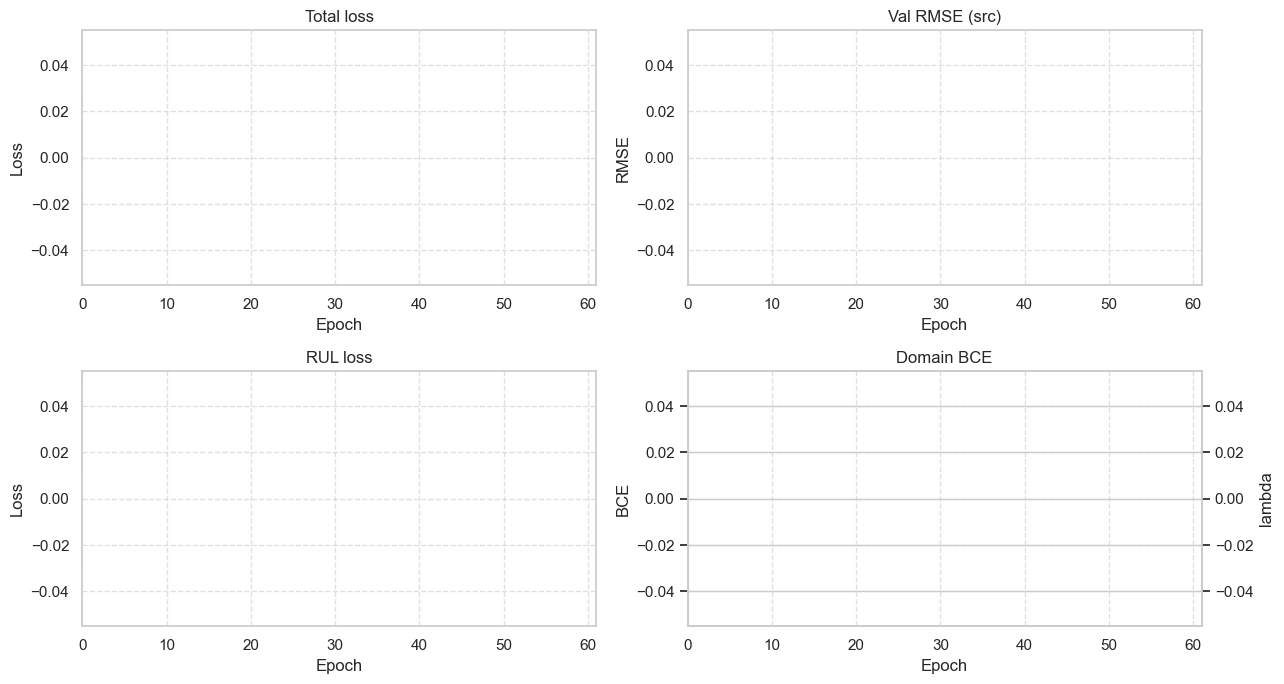

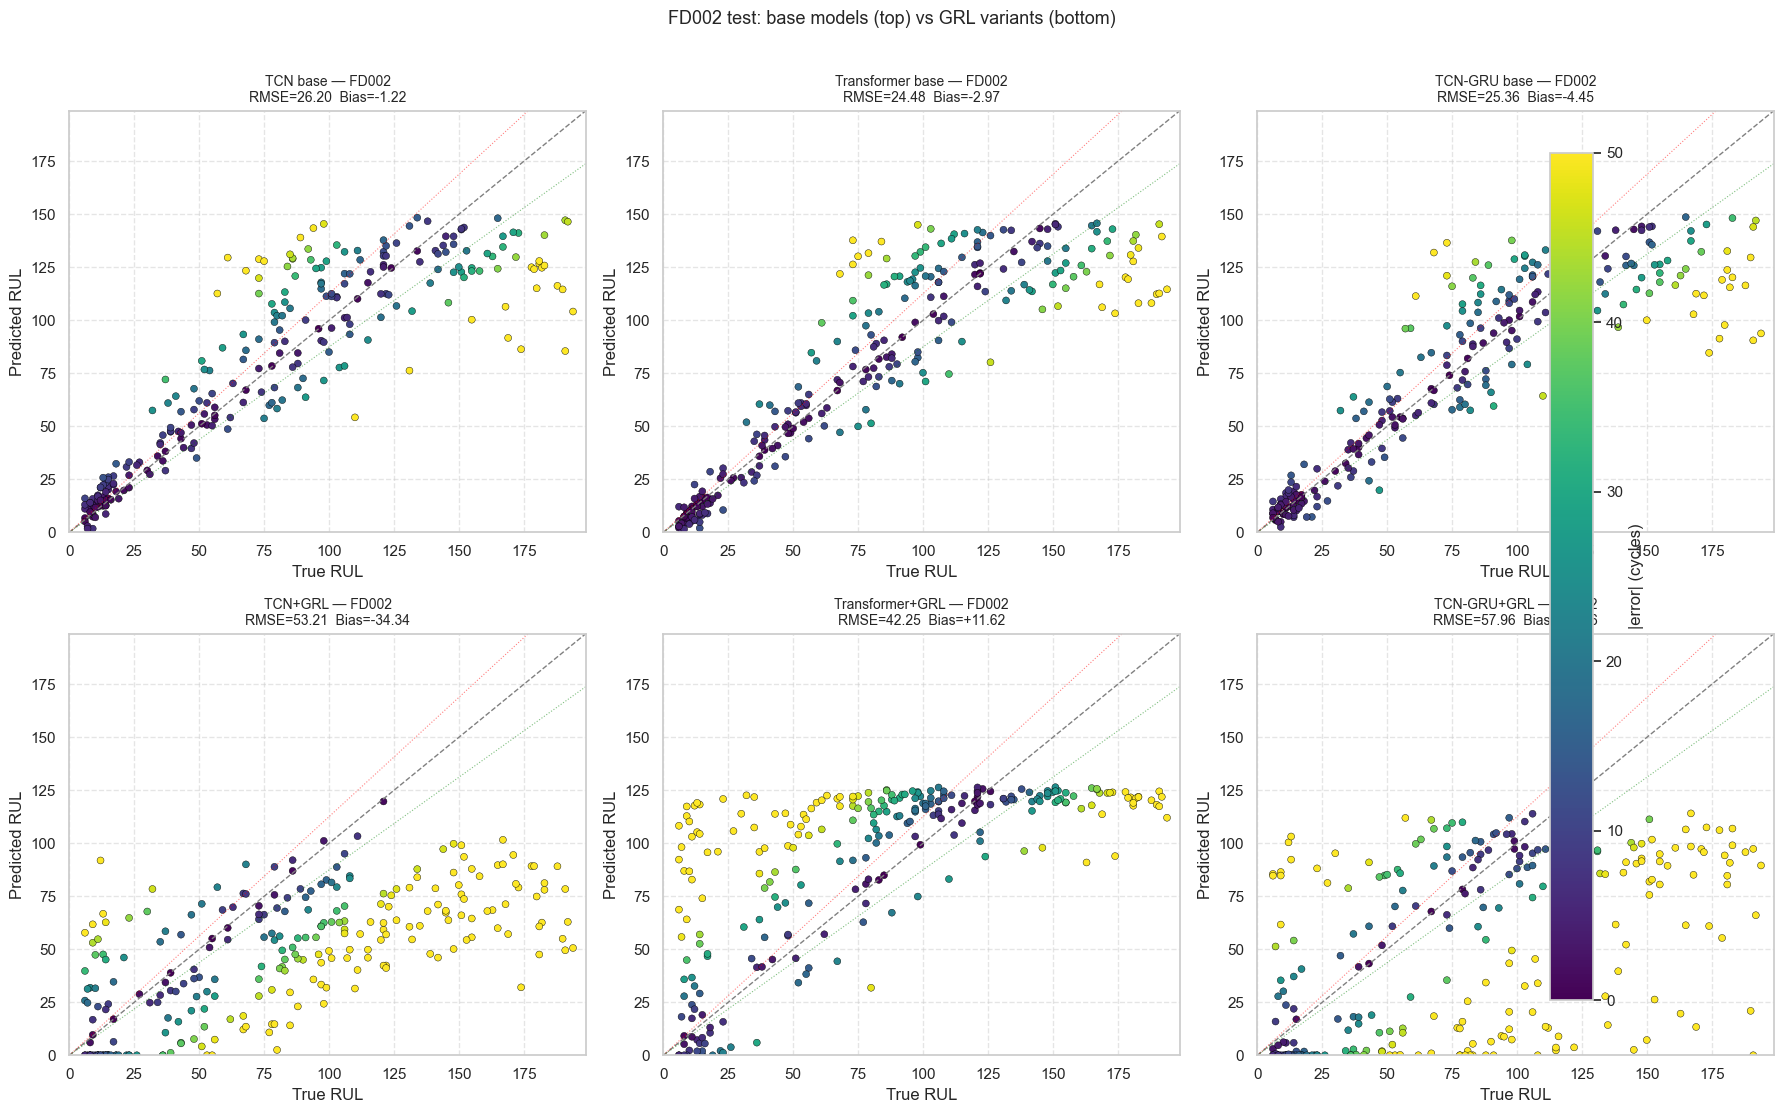

Saved -> figures_v11/v11_base_vs_grl_fd002.png


In [22]:
# ── 6-panel scatter: base vs GRL on FD002 for all 3 architectures ─────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
yt = test_ruls['FD002']

panels = [
    ('TCN (base)',          base_metrics, 'TCN',         model_specs[0][1],  False),
    ('Transformer (base)',  base_metrics, 'Transformer', model_specs[1][1],  False),
    ('TCN-GRU (base)',      base_metrics, 'TCN-GRU',     model_specs[2][1],  False),
]
grl_panels = [
    ('TCN+GRL',         'TCN+GRL',         True),
    ('Transformer+GRL', 'Transformer+GRL', True),
    ('TCN-GRU+GRL',     'TCN-GRU+GRL',    True),
]

# Keep references to GRL models for inference
grl_model_refs = {}

def plot_scatter(ax, y_true, y_pred_raw, title):
    yp  = np.clip(y_pred_raw, 0, None)
    err = np.abs(yp - y_true)
    lim = max(y_true.max(), yp.max()) + 5
    ax.plot([0,lim],[0,lim],'--',color='gray',lw=1)
    ax.plot([0,lim],[0,lim-25],':',color='green',lw=0.8,alpha=0.5)
    ax.plot([0,lim],[0,lim+25],':',color='red',lw=0.8,alpha=0.5)
    sc = ax.scatter(y_true, yp, c=err, cmap='viridis',
                    s=25, edgecolor='black', linewidth=0.3, vmin=0, vmax=50)
    ax.set_xlim(0,lim); ax.set_ylim(0,lim)
    ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
    rmse = math.sqrt(np.mean((yp-y_true)**2))
    bias = float((yp-y_true).mean())
    ax.set_title(f'{title}\nRMSE={rmse:.2f}  Bias={bias:+.2f}', fontsize=10)
    ax.grid(linestyle='--', alpha=0.5)
    return sc

for col, (_, _, enc_name, enc_model, _) in enumerate(panels):
    raw = run_inference(enc_model, test_windows['FD002'], Device)
    sc  = plot_scatter(axes[0, col], yt, raw, f'{enc_name} base — FD002')

# For GRL models we need to find them; they are in grl_model_refs after training
# Re-load from checkpoints
grl_enc_map = [
    ('TCN+GRL',         TCN(len(USE_SENSORS), n_channels=32, dropout=0.2)),
    ('Transformer+GRL', LightweightTransformer(len(USE_SENSORS), d_model=64, nhead=4,
                                               dim_feedforward=128, dropout=0.1)),
    ('TCN-GRU+GRL',     TCNGRUHybrid(len(USE_SENSORS), tcn_channels=32,
                                      gru_hidden=64, dropout=0.2)),
]

for col, (grl_label, encoder) in enumerate(grl_enc_map):
    safe  = grl_label.lower().replace('+','_').replace('-','_')
    ckpt  = CKPT_DIR / f'grl_{safe}.pt'
    gm    = GRLWrapper(encoder).to(Device)
    sd    = torch.load(ckpt, map_location=Device, weights_only=False)
    gm.load_state_dict(sd['model'])
    raw   = run_inference_dann(gm, test_windows['FD002'], Device)
    sc    = plot_scatter(axes[1, col], yt, raw, f'{grl_label} — FD002')

plt.colorbar(sc, ax=axes[:,-1], label='|error| (cycles)')
plt.suptitle('FD002 test: base models (top) vs GRL variants (bottom)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'v11_base_vs_grl_fd002.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v11_base_vs_grl_fd002.png')

In [23]:
# ── Save all results ───────────────────────────────────────────────────────────
final_results = {
    'base':   {n: {s: m for s, m in v.items()} for n, v in base_metrics.items()},
    'grl':    {n: {s: m for s, m in v.items()} for n, v in grl_metrics.items()},
    'config': {
        'window': W, 'rul_clips': RUL_CLIPS,
        'n_features': len(USE_SENSORS),
        'use_sensors': USE_SENSORS,
        'training_subsets': SUBSETS,
        'grl_src': SRC_SUBSETS, 'grl_tgt': TGT_SUBSETS,
        'normalization': 'regression-based residual',
        'loss': 'asymmetric_mse(late_weight=1.3) + 0.3*mse(state)',
        'warmup_epochs': 10, 'total_epochs': 60,
    },
    'references': {
        'v10_transformer_fd001': 14.93, 'v10_transformer_fd002': 25.03,
        'v9_bigru_fd001': 14.58, 'v9_bigru_fd002_lower_bound': 59.51,
        'zheng2017_fd001': 16.10,
    }
}
with open(CKPT_DIR/'v11_all_results.json', 'w') as f:
    json.dump(final_results, f, indent=2, default=float)
print(f'Saved {CKPT_DIR}/v11_all_results.json')
print(f'Checkpoints: {len(list(CKPT_DIR.glob("*.pt")))} .pt files')
print(f'Figures    : {len(list(FIG_DIR.glob("*.png")))} .png files')

Saved checkpoints_v11/v11_all_results.json
Checkpoints: 6 .pt files
Figures    : 2 .png files
